## Milestone 5: Multimodal Classifier Development
This notebook builds the final multimodal classifier using the fused features (320D visual + 12D geometric) generated in Milestone 4.

**Key constraints:**
- **Subject-wise splitting**: No driver overlap between training and validation.
- **Residual MLP**: Custom architecture with skip connections.
- **Leakage Prevention**: Standard scaling (if needed) is fitted only on training subjects.

In [1]:
from google.colab import drive
import shutil
import os

drive.mount("/content/drive")

SOURCE_DIR = "/content/drive/MyDrive/RI/"
REQUIRED_FILES = ["fusion_features.npy", "fusion_labels.npy", "fusion_subjects.npy", "fusion_dataframe.parquet"]

print("Copying Milestone 4 artifacts...")
for f in REQUIRED_FILES:
    src = os.path.join(SOURCE_DIR, f)
    if os.path.exists(src):
        shutil.copy(src, ".")
        print(f"✓ Copied {f}")
    else:
        print(f"✗ Missing {f} in {SOURCE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying Milestone 4 artifacts...
✓ Copied fusion_features.npy
✓ Copied fusion_labels.npy
✓ Copied fusion_subjects.npy
✓ Copied fusion_dataframe.parquet


In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
import time
import json
import random

# Set seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Constants
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


### 1. Data Loading and Verification
We load the files generated in Milestone 4 and verify their dimensions.

In [3]:
# Load Milestone 4 artifacts
fused_features = np.load("fusion_features.npy")
fused_labels = np.load("fusion_labels.npy", allow_pickle=True)
fused_subjects = np.load("fusion_subjects.npy", allow_pickle=True)

# Encode labels (C0-C9 to 0-9)
le = LabelEncoder()
y_encoded = le.fit_transform(fused_labels)

# Verification
unique_subjects = np.unique(fused_subjects)
print("--- Data Verification ---")
print(f"Total Samples: {len(fused_features)}")
print(f"Feature Dimension: {fused_features.shape[1]}")
print(f"Number of Classes: {len(le.classes_)}")
print(f"Number of Unique Subjects: {len(unique_subjects)}")

# Handling NaNs: Milestone 4 handles landmark cleaning, but we ensure zero-imputation
# for any remaining edge cases in geometric features to maintain pipeline stability.
nan_count = np.isnan(fused_features).sum()
if nan_count > 0:
    print(f"Notice: Found {nan_count} NaNs in fusion features. Imputing with 0 to maintain tensor compatibility.")
    fused_features = np.nan_to_num(fused_features, nan=0.0)

--- Data Verification ---
Total Samples: 22424
Feature Dimension: 332
Number of Classes: 10
Number of Unique Subjects: 26
Notice: Found 169188 NaNs in fusion features. Imputing with 0 to maintain tensor compatibility.


### 2. Subject-wise Data Splitting
We split the data by subject to ensure the model generalizes to unseen drivers.

In [4]:
def subject_wise_split(features, labels, subjects, train_ratio=0.8):
    unique_subs = sorted(list(set(subjects)))
    np.random.seed(42)
    random.seed(42)
    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    split_idx = int(len(unique_subs) * train_ratio)
    train_subs = unique_subs[:split_idx]
    val_subs = unique_subs[split_idx:]
    train_mask = np.isin(subjects, train_subs)
    val_mask = np.isin(subjects, val_subs)
    return train_mask, val_mask, train_subs, val_subs

train_mask, val_mask, train_subs, val_subs = subject_wise_split(fused_features, y_encoded, fused_subjects)
X_train, y_train = fused_features[train_mask], y_encoded[train_mask]
X_val, y_val = fused_features[val_mask], y_encoded[val_mask]

print(f"Training: {len(X_train)} samples ({len(train_subs)} subjects)")
print(f"Validation: {len(X_val)} samples ({len(val_subs)} subjects)")

Training: 17778 samples (20 subjects)
Validation: 4646 samples (6 subjects)


### 3. Residual MLP Architecture

In [5]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(dim, dim)
        )
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(self.block(x) + x)

class MultimodalClassifier(nn.Module):
    def __init__(self, input_dim, num_classes=10):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.30)
        )
        self.res_block = ResidualBlock(512, dropout=0.30)
        self.transition = nn.Sequential(
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.30)
        )
        self.classifier = nn.Linear(256, num_classes)
    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_block(x)
        x = self.transition(x)
        return self.classifier(x)

model = MultimodalClassifier(input_dim=X_train.shape[1]).to(DEVICE)
print(f"Model initialized with {sum(p.numel() for p in model.parameters() if p.requires_grad)} parameters.")

Model initialized with 832266 parameters.


### 4. Training Pipeline
Implementing the training loop with mixed precision and early stopping.

In [6]:
from sklearn.utils.class_weight import compute_class_weight

class FusionDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.FloatTensor(x)
        self.y = torch.LongTensor(y)
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]

# Calculate Class Weights based on Training Set
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.FloatTensor(weights).to(DEVICE)

train_loader = DataLoader(FusionDataset(X_train, y_train), batch_size=128, shuffle=True)
val_loader = DataLoader(FusionDataset(X_val, y_val), batch_size=128, shuffle=False)

# Updated Loss with Class Weights
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)
scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None

### 5. Training Loop
We implement the training loop with mixed precision (if CUDA is available) and track history for visualization.

In [7]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=100, patience=10):
    model = model.to(DEVICE)
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'macro_precision': [], 'macro_recall': [],
        'macro_f1': [], 'balanced_accuracy': [],
        'learning_rate': []
    }
    best_val_f1 = 0.0
    early_stop_counter = 0

    print(f"Starting training on {DEVICE}...")

    for epoch in range(num_epochs):
        model.train()
        train_loss, train_correct = 0, 0
        for inputs, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False):
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()

            if scaler:
                with torch.amp.autocast('cuda'):
                    outputs = model(inputs)
                    loss = criterion(outputs, targets)
                scaler.scale(loss).backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            train_correct += predicted.eq(targets).sum().item()

        # Validation
        model.eval()
        val_loss = 0
        val_preds, val_targets = [], []
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)

                _, predicted = outputs.max(1)
                val_preds.extend(predicted.cpu().numpy())
                val_targets.extend(targets.cpu().numpy())

        # Calculate Metrics
        epoch_train_loss = train_loss / len(train_loader.dataset)
        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_train_acc = train_correct / len(train_loader.dataset)

        precision, recall, f1, _ = precision_recall_fscore_support(val_targets, val_preds, average='macro', zero_division=0)
        bal_acc = balanced_accuracy_score(val_targets, val_preds)
        val_acc = (np.array(val_preds) == np.array(val_targets)).mean()

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(val_acc)
        history['macro_precision'].append(precision)
        history['macro_recall'].append(recall)
        history['macro_f1'].append(f1)
        history['balanced_accuracy'].append(bal_acc)
        history['learning_rate'].append(optimizer.param_groups[0]['lr'])

        scheduler.step(epoch_val_loss)

        print(f"Epoch {epoch+1}: Val Loss: {epoch_val_loss:.4f} | Val Acc: {val_acc:.4f} | Macro F1: {f1:.4f}")

        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_f1': best_val_f1,
            'history': history
        }

        # Best Model Selection based on Macro F1
        if f1 > best_val_f1:
            best_val_f1 = f1
            checkpoint['best_val_f1'] = best_val_f1
            torch.save(checkpoint, OUTPUT_DIR / 'best_classifier.pth')
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        torch.save(checkpoint, OUTPUT_DIR / 'latest_classifier.pth')
        if early_stop_counter >= patience: break

    return history

training_history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler)

Starting training on cuda...


Epoch 1/100 [Train]:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 1: Val Loss: 0.1776 | Val Acc: 0.9477 | Macro F1: 0.9479


Epoch 2/100 [Train]:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 2: Val Loss: 0.1931 | Val Acc: 0.9415 | Macro F1: 0.9422


...

Epoch 16: Val Loss: 0.3057 | Val Acc: 0.9391 | Macro F1: 0.9398


Epoch 17/100 [Train]:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 17: Val Loss: 0.3082 | Val Acc: 0.9372 | Macro F1: 0.9382


Epoch 18/100 [Train]:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 18: Val Loss: 0.2836 | Val Acc: 0.9494 | Macro F1: 0.9502


### 6. Evaluation and Visualization
Final performance analysis on the validation set using the best saved model.

--- Final Classification Report ---
              precision    recall  f1-score   support

          c0       0.95      0.83      0.89       540
          c1       0.95      0.99      0.97       495
          c2       1.00      0.98      0.99       487
          c3       0.98      0.99      0.98       460
          c4       0.99      0.96      0.97       467
          c5       1.00      0.98      0.99       433
          c6       0.98      0.94      0.96       463
          c7       0.96      0.99      0.98       405
          c8       0.92      0.94      0.93       437
          c9       0.82      0.96      0.88       459

    accuracy                           0.95      4646
   macro avg       0.95      0.95      0.95      4646
weighted avg       0.95      0.95      0.95      4646



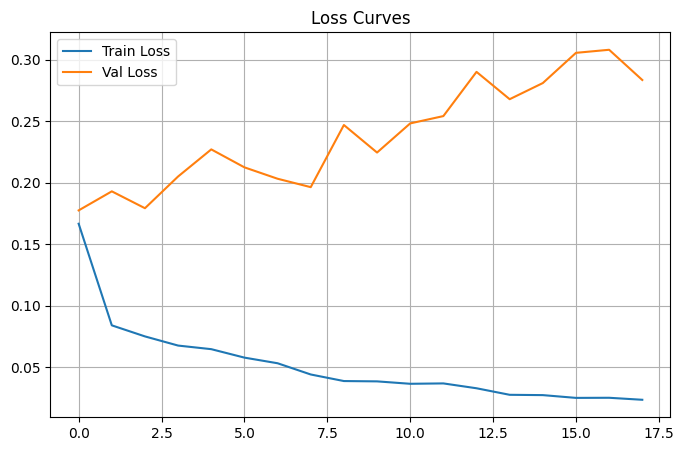

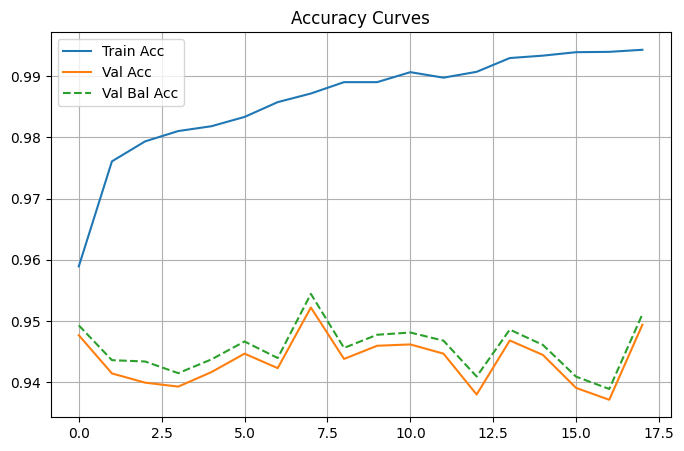

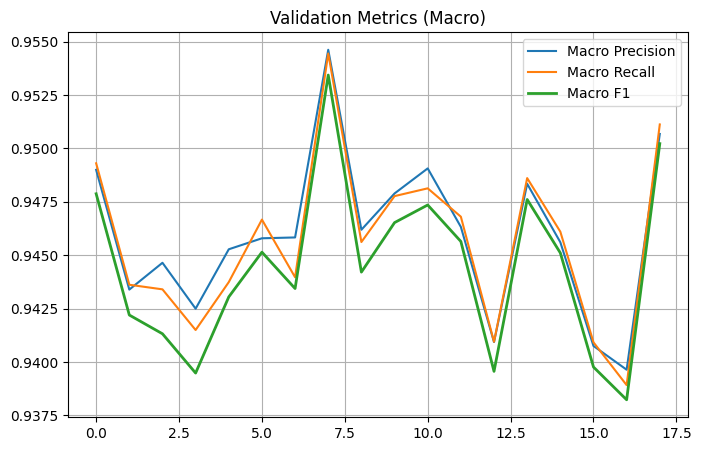

In [8]:
# Load best model and history
# Note: weights_only=False is used because the checkpoint contains the history dictionary and scheduler states
checkpoint = torch.load(OUTPUT_DIR / 'best_classifier.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for inputs, targets in val_loader:
        outputs = model(inputs.to(DEVICE))
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.numpy())

report = classification_report(all_targets, all_preds, target_names=le.classes_)
print("--- Final Classification Report ---")
print(report)

# Save artifacts
pd.DataFrame(training_history).to_csv(OUTPUT_DIR / 'training_history.csv', index=False)
with open(OUTPUT_DIR / 'classification_report.txt', 'w') as f: f.write(report)

# 1. Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(training_history['train_loss'], label='Train Loss')
plt.plot(training_history['val_loss'], label='Val Loss')
plt.title('Loss Curves'); plt.legend(); plt.grid(True)
plt.savefig(OUTPUT_DIR / 'loss_curve.png'); plt.show()

# 2. Accuracy Curve
plt.figure(figsize=(8, 5))
plt.plot(training_history['train_acc'], label='Train Acc')
plt.plot(training_history['val_acc'], label='Val Acc')
plt.plot(training_history['balanced_accuracy'], label='Val Bal Acc', linestyle='--')
plt.title('Accuracy Curves'); plt.legend(); plt.grid(True)
plt.savefig(OUTPUT_DIR / 'accuracy_curve.png'); plt.show()

# 3. Precision-Recall-F1 Curve
plt.figure(figsize=(8, 5))
plt.plot(training_history['macro_precision'], label='Macro Precision')
plt.plot(training_history['macro_recall'], label='Macro Recall')
plt.plot(training_history['macro_f1'], label='Macro F1', linewidth=2)
plt.title('Validation Metrics (Macro)'); plt.legend(); plt.grid(True)
plt.savefig(OUTPUT_DIR / 'precision_recall_f1.png'); plt.show()

### 7. Detailed Error Analysis
We visualize the confusion matrix and per-class accuracy to identify specific driving postures that might be confused.

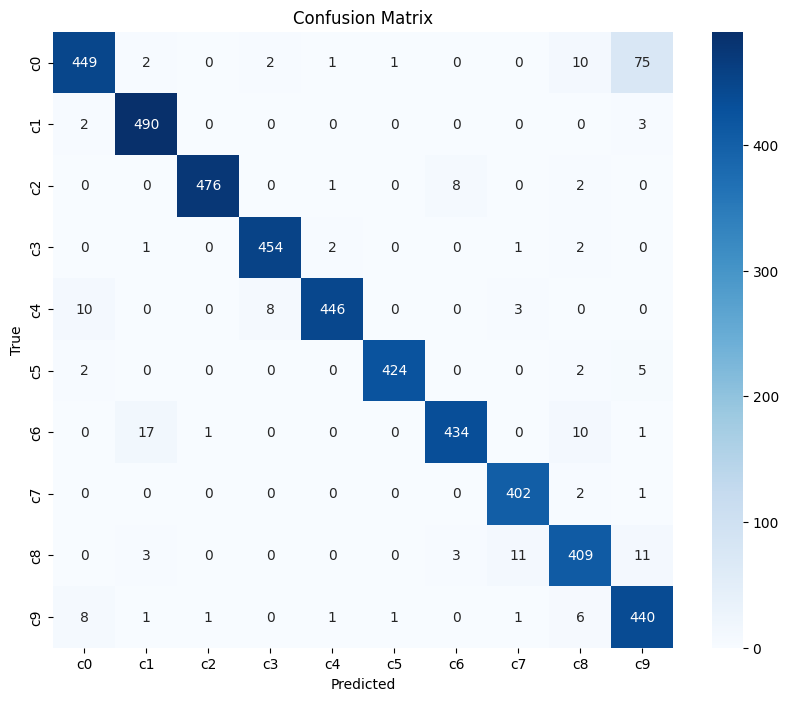

/tmp/ipykernel_5964/2827450814.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=le.classes_, y=class_accuracies, palette='viridis')


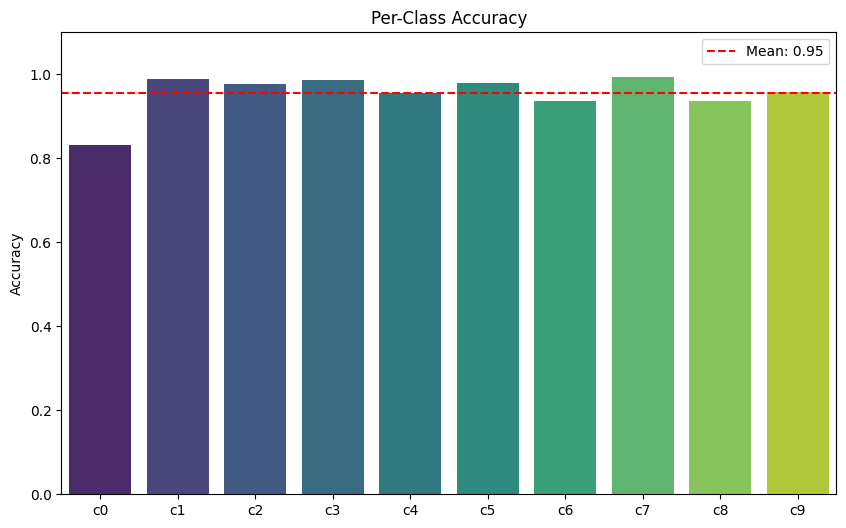

--- Milestone 5 Validation Summary ---
Best Validation Accuracy: 0.9522
Final Input Dimension: 332
Total Trainable Parameters: 832266
Artifacts saved to: outputs/


In [9]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png')
plt.show()

# Per-class accuracy chart
class_accuracies = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(10, 6))
sns.barplot(x=le.classes_, y=class_accuracies, palette='viridis')
plt.axhline(y=np.mean(class_accuracies), color='r', linestyle='--', label=f'Mean: {np.mean(class_accuracies):.2f}')
plt.title('Per-Class Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.legend()
plt.savefig(OUTPUT_DIR / 'per_class_accuracy.png')
plt.show()

# Summary Validation Print
print("--- Milestone 5 Validation Summary ---")
print(f"Best Validation Accuracy: {max(training_history['val_acc']):.4f}")
print(f"Final Input Dimension: {X_train.shape[1]}")
print(f"Total Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
print(f"Artifacts saved to: {OUTPUT_DIR}/")